<a href="https://colab.research.google.com/github/Anusree-ss780/ML-LAB/blob/main/EXP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-09-23 09:00:59--  https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10118 (9.9K) [text/plain]
Saving to: ‘auto-mpg.csv’

auto-mpg.csv        100%[===================>]   9.88K  --.-KB/s    in 0s      

2026-09-23 09:01:00 (57.6 MB/s) - ‘auto-mpg.csv’ saved [10118/10118]

                              Model    MSE  R2 Score
0                 Linear Regression  22.30      0.57
1  Polynomial Regression (Degree 2)  21.66      0.58
2  Polynomial Regression (Degree 3)  22.15      0.57


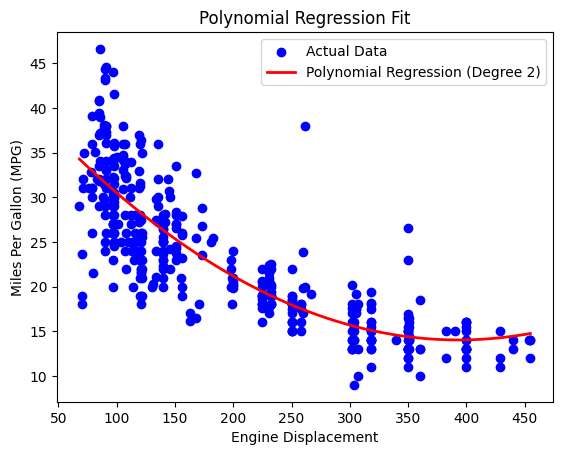

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Download the dataset if it's not present
!wget -nc https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv

data = pd.read_csv("auto-mpg.csv", na_values="?")
data.dropna(inplace=True)
data["displacement"] = data["displacement"].astype(float)

X = data[["displacement"]]
y = data["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)
poly_model2 = LinearRegression()
poly_model2.fit(X_train_poly2, y_train)
y_pred_poly2 = poly_model2.predict(X_test_poly2)
poly2_mse = mean_squared_error(y_test, y_pred_poly2)
poly2_r2 = r2_score(y_test, y_pred_poly2)

poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)
poly_model3 = LinearRegression()
poly_model3.fit(X_train_poly3, y_train)
y_pred_poly3 = poly_model3.predict(X_test_poly3)
poly3_mse = mean_squared_error(y_test, y_pred_poly3)
poly3_r2 = r2_score(y_test, y_pred_poly3)

comparison = pd.DataFrame({
    "Model":["Linear Regression","Polynomial Regression (Degree 2)","Polynomial Regression (Degree 3)"],
    "MSE":[round(linear_mse,2),round(poly2_mse,2),round(poly3_mse,2)],
    "R2 Score":[round(linear_r2,2),round(poly2_r2,2),round(poly3_r2,2)]
})

print(comparison)

X_plot = pd.DataFrame(
    np.linspace(X["displacement"].min(), X["displacement"].max(),300),
    columns=["displacement"]
)

X_plot_poly = poly2.transform(X_plot)
y_plot = poly_model2.predict(X_plot_poly)

plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X_plot["displacement"], y_plot, color="red", linewidth=2,
         label="Polynomial Regression (Degree 2)")
plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.show()

In [5]:
degrees = [2,3,4]

for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    print("\nDegree =", degree)
    print("MSE =", mean_squared_error(y_test, y_pred))
    print("R2 =", r2_score(y_test, y_pred))


Degree = 2
MSE = 21.661070550932806
R2 = 0.5824993665823681

Degree = 3
MSE = 22.145124438795076
R2 = 0.5731695966471484

Degree = 4
MSE = 22.746531300220195
R2 = 0.5615779375462604


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


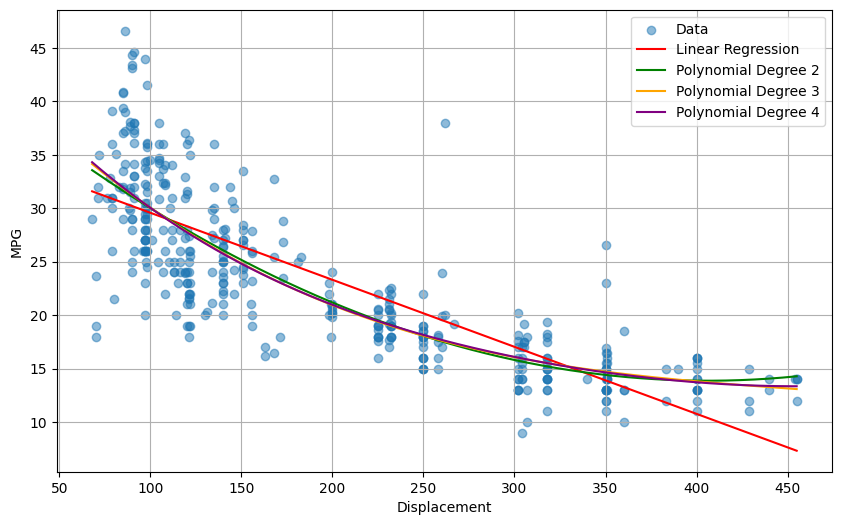

In [6]:
# Visualization

x_range = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

plt.figure(figsize=(10,6))
plt.scatter(X,y,alpha=0.5,label='Data')

plt.plot(x_range,
         linear_model.predict(x_range),
         color='red',
         label='Linear Regression')

colors=['green','orange','purple']

for degree,color in zip([2,3,4],colors):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly,y)

    plt.plot(x_range,
             model.predict(poly.transform(x_range)),
             color=color,
             label=f'Polynomial Degree {degree}')

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.legend()
plt.grid()
plt.show()